In [ ]:
#Library Import
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
#Importing Training Data
import pandas as pd
from google.colab import files
uploaded = files.upload()
dataset_train = pd.read_csv("Google_Stock_Price_Train.csv")
print(dataset_train.head())

Saving Google_Stock_Price_Train.csv to Google_Stock_Price_Train (2).csv
         Date    Open    High     Low   Close       Volume
0  01-03-2012  325.25  332.83  324.97  663.59    73,80,500
1  01-04-2012  331.27  333.87  329.08  666.45    57,49,400
2  01-05-2012  329.83  330.75  326.89  657.21    65,90,300
3  01-06-2012  328.34  328.77  323.68  648.24    54,05,900
4  01-09-2012  322.04  322.29  309.46  620.76  1,16,88,800


In [ ]:
#Took Open Price only to Predict future Open Price
training_set = dataset_train.iloc[:, 1:2].values

In [ ]:
# Scaling
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler()
training_set_scaled = sc.fit_transform(training_set)

In [ ]:
#60 Timesteps Structure
X_train = []
y_train = []
for i in range(60, 1258):
    X_train.append(training_set_scaled[i-60:i, 0])
    y_train.append(training_set_scaled[i, 0])

X_train, y_train = np.array(X_train), np.array(y_train)

In [ ]:
# LSTM/RNN in Keras requires input in 3D format
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout

In [ ]:
# Regression problem
regressor = Sequential()

In [ ]:
# LSTM Layers with Dropout
regressor.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
regressor.add(Dropout(0.2)) #Layer 1
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2)) #Layer 2
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2)) #Layer 3
regressor.add(LSTM(units=50)) #Layer 4 LSTM (Last)
regressor.add(Dropout(0.2))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
#Output Layer
regressor.add(Dense(units=1))

In [ ]:
#Compiling
regressor.compile(optimizer='adam', loss='mean_squared_error')

In [ ]:
#Training
regressor.fit(X_train, y_train, epochs=50, batch_size=32)
pred = regressor.predict(X_train)

Epoch 1/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 94ms/step - loss: 0.0430
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 112ms/step - loss: 0.0064
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step - loss: 0.0056
Epoch 4/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 93ms/step - loss: 0.0051
Epoch 5/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 114ms/step - loss: 0.0046
Epoch 6/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 95ms/step - loss: 0.0048
Epoch 7/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - loss: 0.0050
Epoch 8/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - loss: 0.0046
Epoch 9/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 129ms/step - loss: 0.0046
Epoch 10/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - loss: 0.0046
Epoch 11/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 92ms/step - loss: 0.0047
Epoch 12/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 133ms/step - loss: 0.0046
Epoch 13/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 95ms/step - loss: 0.0043
Epoch 14/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - loss: 0.0040
Epoch 15/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 127ms/step - loss: 0.0

In [ ]:
#Evaluating RMSE
import math
from sklearn.metrics import mean_squared_error
rmse = math.sqrt(mean_squared_error(y_train, pred))
rmse
# Output: 0.0270

0.03173834107371986

In [ ]:
#Loading Test Data
from google.colab import files
uploaded = files.upload()
dataset_test = pd.read_csv("Google_Stock_Price_Test.csv")
print(dataset_test.head())
real_stock_price = dataset_test.iloc[:, 1:2].values

Saving Google_Stock_Price_Test.csv to Google_Stock_Price_Test (1).csv
       Date    Open    High     Low   Close     Volume
0  1/3/2017  778.81  789.63  775.80  786.14  1,657,300
1  1/4/2017  788.36  791.34  783.16  786.90  1,073,000
2  1/5/2017  786.08  794.48  785.02  794.02  1,335,200
3  1/6/2017  795.26  807.90  792.20  806.15  1,640,200
4  1/9/2017  806.40  809.97  802.83  806.65  1,272,400


In [ ]:
#Preparing Test Input
dataset_total = pd.concat((dataset_train['Open'], dataset_test['Open']), axis=0)
inputs = dataset_total[len(dataset_total) - len(dataset_test) - 60:].values
inputs = inputs.reshape(-1, 1)
inputs = sc.transform(inputs)

In [ ]:
X_test = []
for i in range(60, 80):
    X_test.append(inputs[i-60:i, 0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

In [ ]:
# Predicting and Inverse Scaling
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


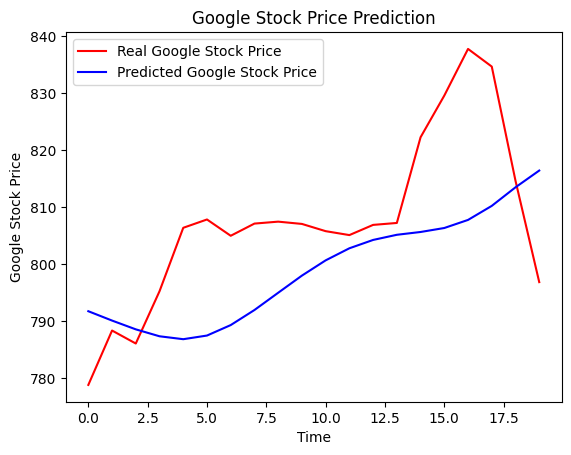

In [ ]:
#Visualisation
plt.plot(real_stock_price, color='red', label='Real Google Stock Price')
plt.plot(predicted_stock_price, color='blue', label='Predicted Google Stock Price')
plt.title('Google Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Google Stock Price')
plt.legend()
plt.show()